In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [72]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [73]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [74]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [75]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


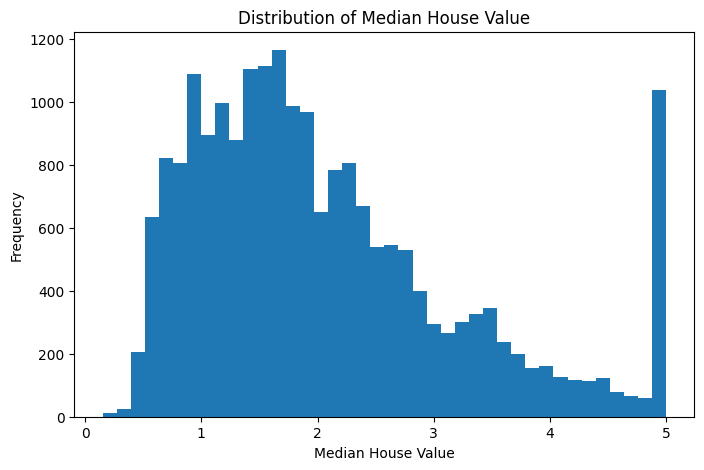

In [76]:
plt.figure(figsize=(8,5))

plt.hist(df["MedHouseVal"], bins=40)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")

plt.show()

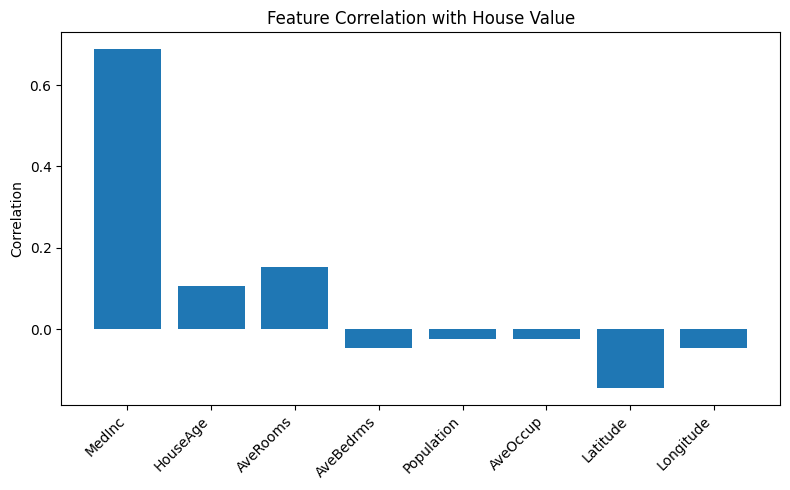

In [77]:
correlations = df.drop('MedHouseVal', axis=1).corrwith(df['MedHouseVal'])

plt.figure(figsize=(8,5))

plt.bar(correlations.index, correlations.values)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation")
plt.title("Feature Correlation with House Value")

plt.tight_layout()
plt.show()

In [78]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [80]:
model = LinearRegression()

In [81]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [82]:
y_pred = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [83]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [84]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.5332001304956553


In [85]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.7455813830127764


In [86]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5757877060324508


In [87]:
print("----- MODEL EVALUATION -----")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

----- MODEL EVALUATION -----
MAE  : 0.5332
RMSE : 0.7456
R²   : 0.5758


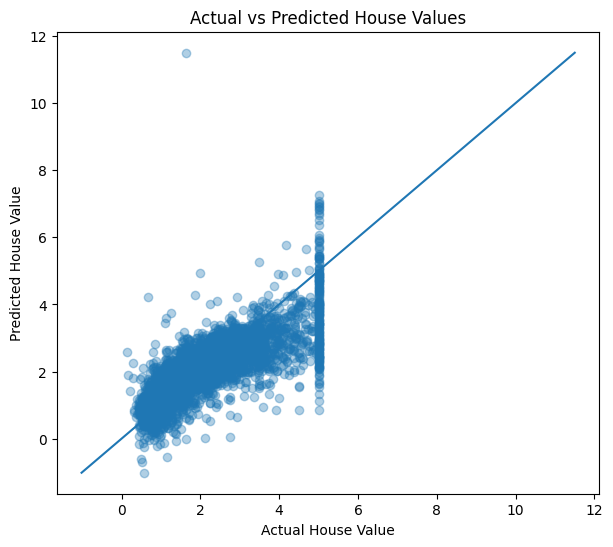

In [88]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.35)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

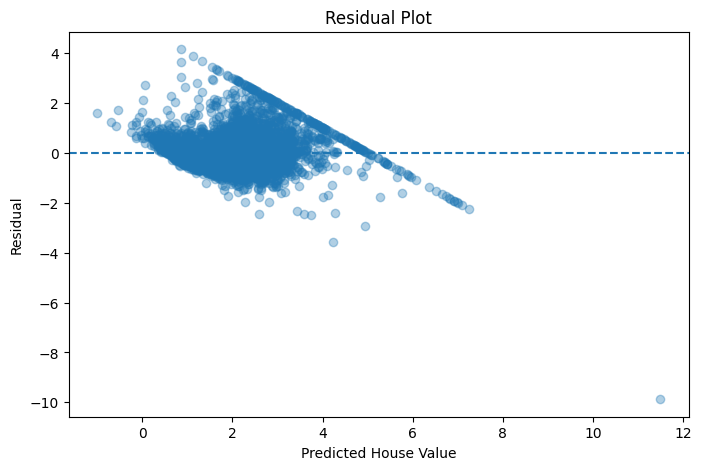

In [89]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.35)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [90]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [91]:
with open("california_housing_linear_regression.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully.")

Model saved successfully.


In [92]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]

print("Input:")
display(sample)

print("Predicted House Value:", prediction)
print("Actual House Value:", y_test.iloc[0])

Input:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01


Predicted House Value: 0.7191228416019086
Actual House Value: 0.477


## Conclusion

In this project, a Linear Regression model was developed to predict house values using the California Housing dataset. The complete machine learning workflow was performed, including data loading, exploratory data analysis, preprocessing, train-test splitting, model training, prediction, and evaluation.

The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. Actual versus predicted and residual plots were also created to understand model performance.

Future improvements can include feature engineering, Ridge and Lasso Regression, Random Forest Regression, Gradient Boosting, cross-validation, and hyperparameter tuning.